<a href="https://colab.research.google.com/github/Clint07-datascientist/AgroInsightX_Chatbot/blob/main/notebooks/chatbot_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Replace file path with GIT_URL
GIT_URL = "https://github.com/Clint07-datascientist/AgroInsightX_Chatbot.git"

# Clone the repository to the Colab environment
!git clone $GIT_URL

Cloning into 'AgroInsightX_Chatbot'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 23 (delta 5), reused 14 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 1.65 MiB | 9.81 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [2]:
from datasets import load_dataset

dataset = load_dataset('parquet', data_files='/content/AgroInsightX_Chatbot/data/agriculture-qa-english-only.parquet')

Generating train split: 0 examples [00:00, ? examples/s]

#**EXPLORATORY DATA ANALYSIS**

In [3]:
# Check column names and number of rows
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['question', 'answers'],
        num_rows: 22615
    })
})


In [4]:
# Check column names and number of rows
print(dataset['train'].features)

{'question': Value('string'), 'answers': Value('string')}


In [5]:
# Check for missing values (requires converting to a pandas DataFrame first)
import pandas as pd
df = dataset['train'].to_pandas()
print(df.isnull().sum())

question    0
answers     0
dtype: int64


In [6]:
# Text length distribution (for 'question' column)
df['question_length'] = df['question'].apply(lambda x: len(str(x).split()))
print(df['question_length'].describe())

count    22615.000000
mean         8.795755
std          3.867245
min          2.000000
25%          6.000000
50%          8.000000
75%         11.000000
max         41.000000
Name: question_length, dtype: float64


In [7]:
# Example of text length distribution (for 'answer' column)
df['answers_length'] = df['answers'].apply(lambda x: len(str(x).split()))
print(df['answers_length'].describe())

count    22615.000000
mean        23.443201
std         31.392871
min          1.000000
25%          5.000000
50%         15.000000
75%         29.000000
max        348.000000
Name: answers_length, dtype: float64


In [8]:
print("Dataset Overview:")
print("=" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Number of reviews: {len(df)}")
print(f"Number of features: {len(df.columns)}")

Dataset Overview:
Dataset shape: (22615, 4)
Number of reviews: 22615
Number of features: 4


In [9]:
# Basic dataset information
print("\nDataset Information:")
print("=" * 50)
print(df.info())
print("\nFirst few rows:")
print("=" * 50)
print(df.head())
print("\nColumn names:")
print("=" * 50)
print(df.columns.tolist())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22615 entries, 0 to 22614
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   question         22615 non-null  object
 1   answers          22615 non-null  object
 2   question_length  22615 non-null  int64 
 3   answers_length   22615 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 706.8+ KB
None

First few rows:
                                            question  \
0         why is crop rotation important in farming?   
1  What farming practice helps prevent soil erosion?   
2                              what is crop rotation   
3      what are the different methods of irrigation?   
4                          why is soil health vital?   

                                             answers  question_length  \
0  This helps to prevent soil erosion and depleti...                7   
1                                      Crop

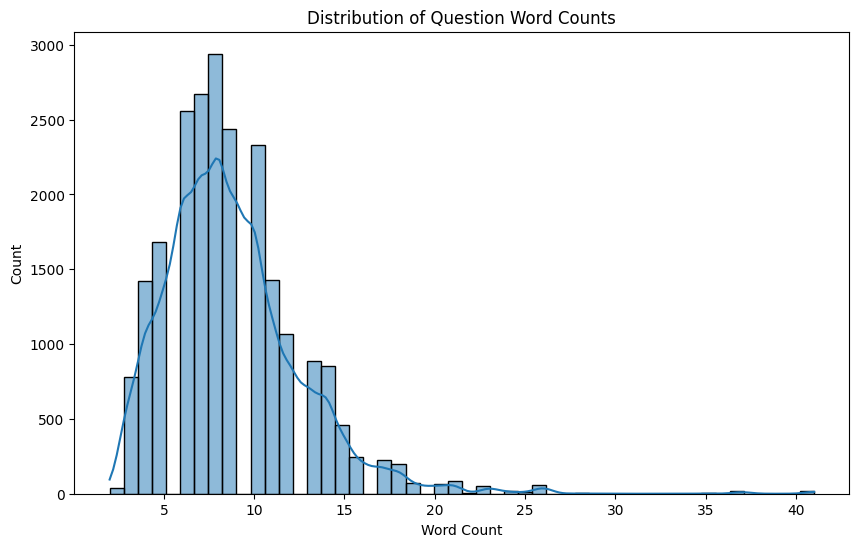

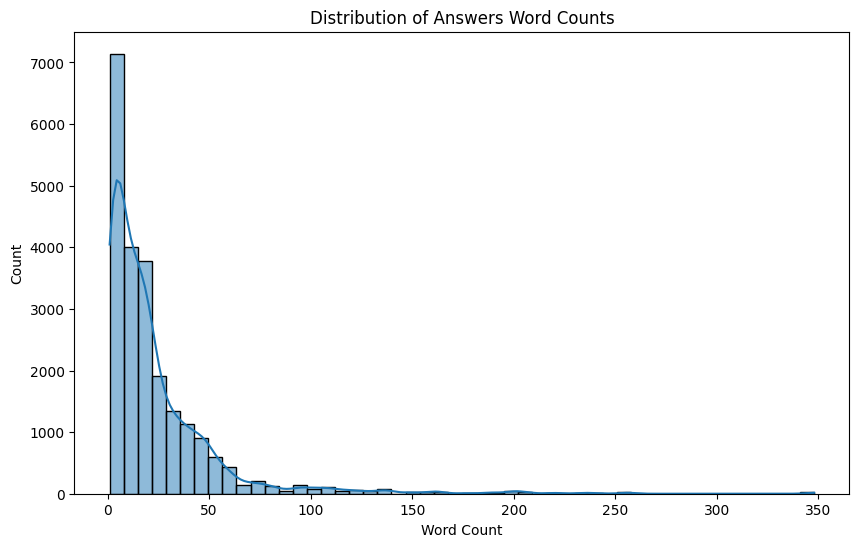

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


# Visualize the distribution of question lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['question_length'], bins=50, kde=True)
plt.title('Distribution of Question Word Counts')
plt.xlabel('Word Count')
plt.show()

# Visualize the distribution of answers lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['answers_length'], bins=50, kde=True)
plt.title('Distribution of Answers Word Counts')
plt.xlabel('Word Count')
plt.show()

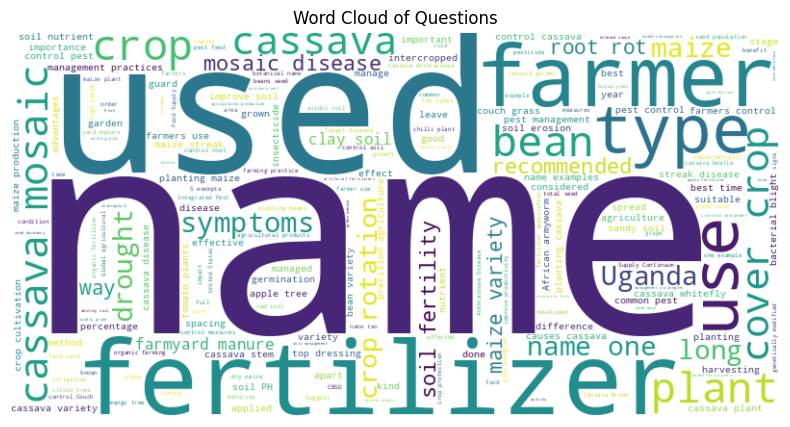

In [11]:
from wordcloud import WordCloud

# Create a single string of all questions
all_questions = ' '.join(df['question'].tolist())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_questions)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Questions')
plt.show()

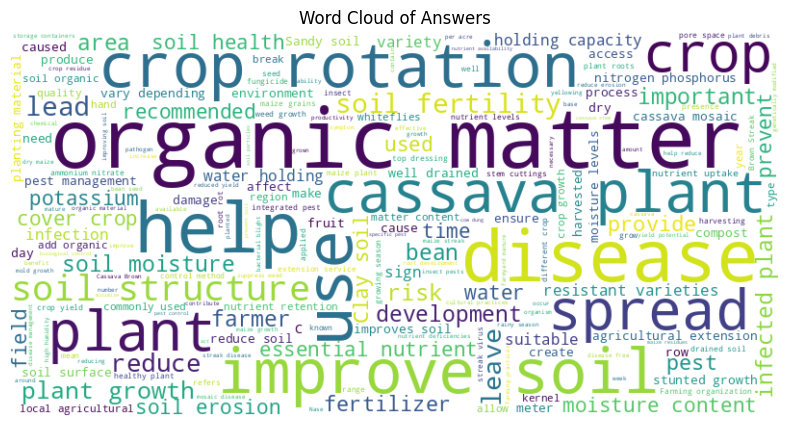

In [12]:
# Create a single string of all answers
all_answers = ' '.join(df['answers'].tolist())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_answers)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Answers')
plt.show()

In [13]:
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Download necessary NLTK data (if you haven't already)
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [14]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [16]:
from nltk.corpus import stopwords

# Define a function to extract n-grams
def get_ngrams(text, n=1, stop_words=None):
    tokens = nltk.word_tokenize(text.lower())
    if stop_words:
        tokens = [word for word in tokens if word not in stop_words]
    if n == 1:
        return tokens  # Return a flat list of tokens for unigrams
    ngrams = [(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
    # Join bigrams into single strings for easier counting
    if n > 1:
        ngrams = [" ".join(ngram) for ngram in ngrams]
    return ngrams

# Get English stop words
stop_words = set(stopwords.words('english'))

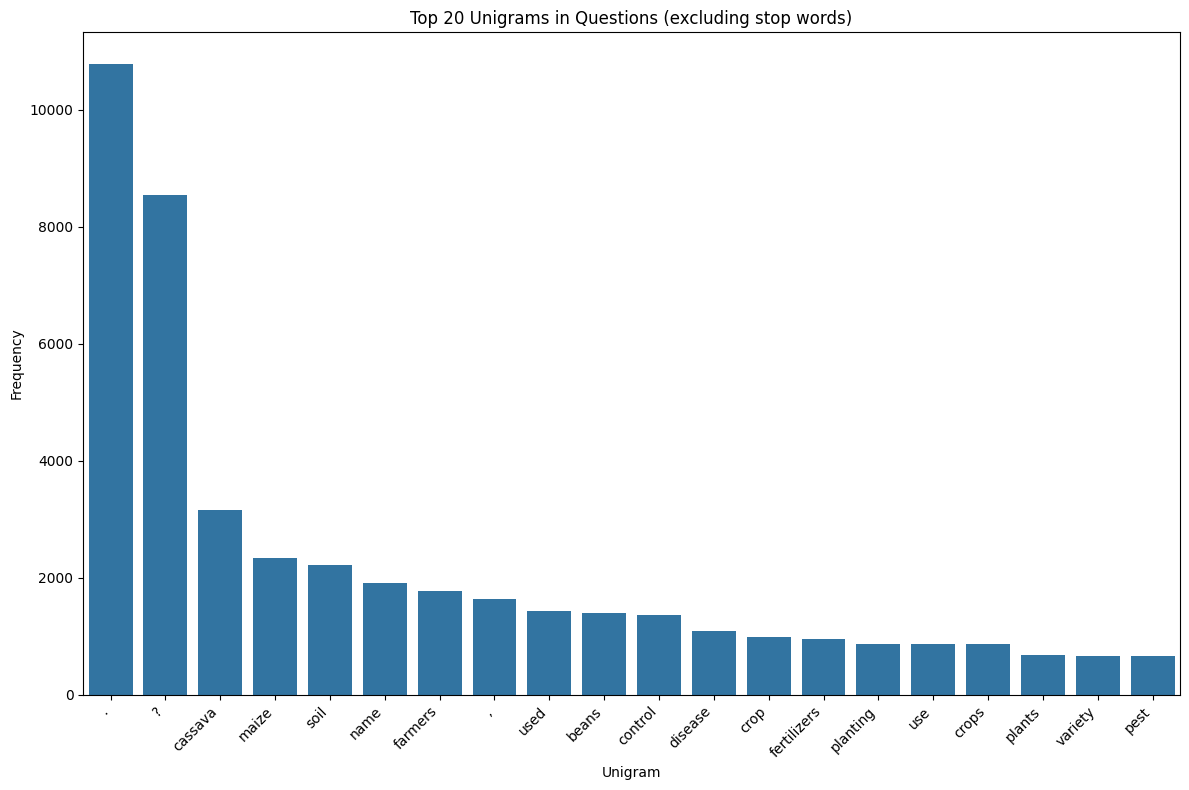

In [17]:
# Analyze and visualize top unigrams in questions
question_unigrams = get_ngrams(' '.join(df['question'].tolist()), n=1, stop_words=stop_words)
question_unigram_counts = Counter(question_unigrams)
top_question_unigrams = question_unigram_counts.most_common(20)

# Plotting the top unigrams
plt.figure(figsize=(12, 8))
sns.barplot(x=[word for word, count in top_question_unigrams], y=[count for word, count in top_question_unigrams])
plt.title('Top 20 Unigrams in Questions (excluding stop words)')
plt.xlabel('Unigram')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

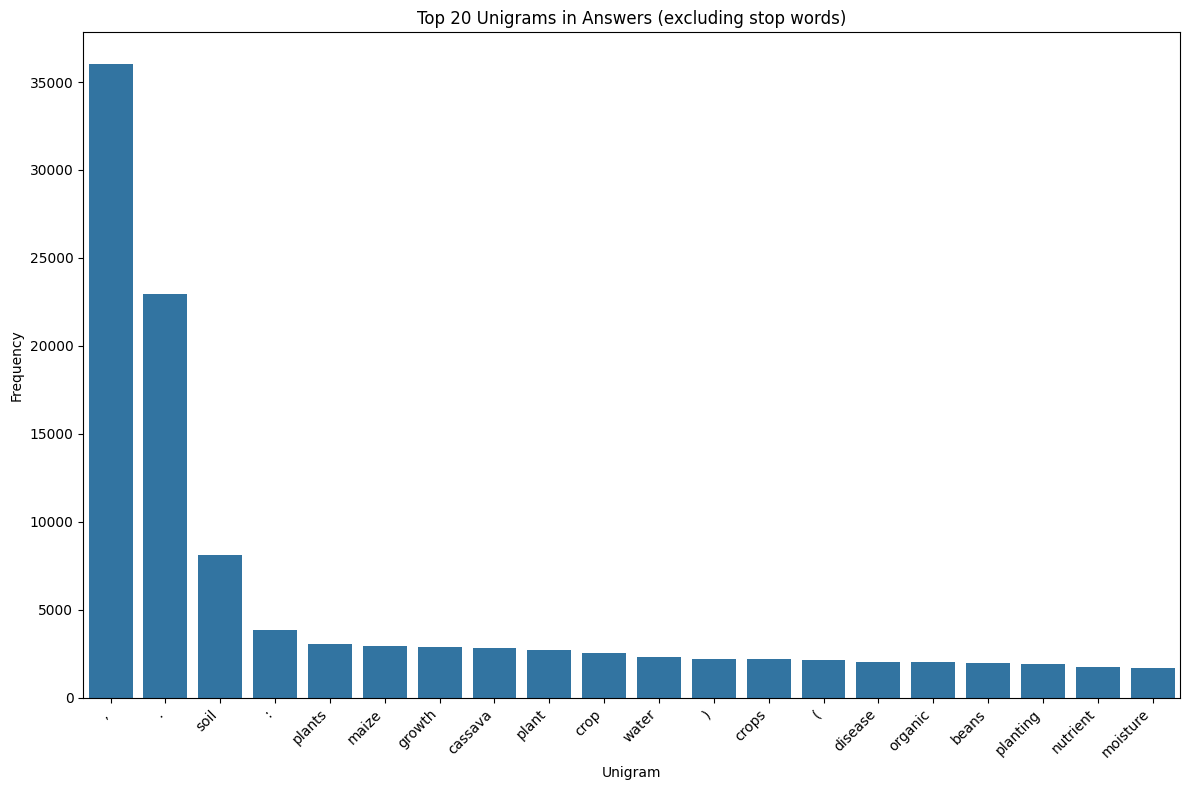

In [18]:
# Analyze and visualize top unigrams in answers
answer_unigrams = get_ngrams(' '.join(df['answers'].tolist()), n=1, stop_words=stop_words)
answer_unigram_counts = Counter(answer_unigrams)
top_answer_unigrams = answer_unigram_counts.most_common(20)

# Plotting the top unigrams
plt.figure(figsize=(12, 8))
sns.barplot(x=[word for word, count in top_answer_unigrams], y=[count for word, count in top_answer_unigrams])
plt.title('Top 20 Unigrams in Answers (excluding stop words)')
plt.xlabel('Unigram')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#**Data Preprocessing**

In [19]:
from transformers import AutoTokenizer

# Choose a model you intend to use, e.g., 'bert-base-uncased'
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [20]:
def preprocess_function(examples):
    questions = [q.strip() for q in examples["question"]]
    answers = examples["answers"]

    # Tokenize the question and answer text with padding and truncation
    inputs = tokenizer(
        questions,
        answers,
        max_length=512,
        truncation="only_second",  # Truncate only the answer if combined length exceeds max_length
        padding="max_length",
        return_offsets_mapping=True, # Return mapping from token to character span in the original text
    )

    offset_mapping = inputs.pop("offset_mapping")
    start_positions = []
    end_positions = []

    for i, offsets in enumerate(offset_mapping):
        answer = answers[i]
        # Find the start and end character indices of the answer in the original text
        start_char = examples["answers"][i].find(answer)
        end_char = start_char + len(answer)

        # Find the start and end token indices of the answer in the tokenized sequence
        start_token = -1
        end_token = -1
        for token_idx, (start, end) in enumerate(offsets):
            if start == start_char:
                start_token = token_idx
            if end == end_char:
                end_token = token_idx
                break # Found the end token, no need to continue

        start_positions.append(start_token)
        end_positions.append(end_token)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

In [21]:
# Split the 'train' split into 90% train and 10% validation
train_test_split = dataset['train'].train_test_split(test_size=0.1)
dataset['train'] = train_test_split['train']
dataset['validation'] = train_test_split['test']

In [22]:
# Apply the function across the whole dataset AFTER splitting
tokenized_dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/20353 [00:00<?, ? examples/s]

Map:   0%|          | 0/2262 [00:00<?, ? examples/s]

# Task
Explain the next steps in training an AgroInsightX chatbot after data preprocessing.

## Choose a model

### Subtask:
Select a pre-trained model suitable for question answering tasks, such as a transformer-based model.


**Reasoning**:
Select a suitable pre-trained model for question answering. 'bert-base-uncased' is a common choice for such tasks and was already used for tokenization, making it a consistent choice for the model as well.



In [23]:
from transformers import AutoModelForQuestionAnswering

# Load a pre-trained model suitable for question answering
model = AutoModelForQuestionAnswering.from_pretrained(model_checkpoint)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Fine-tune the model

### Subtask:
Adapt the chosen model to your specific agriculture QA dataset.


**Reasoning**:
Define the training arguments and create a Trainer object for fine-tuning the model on the dataset.



**Reasoning**:
The previous command failed because `evaluation_strategy` is not a valid argument for `TrainingArguments`. I need to update the `TrainingArguments` to use `eval_strategy` instead.



**Reasoning**:
The traceback indicates a KeyError because the key 'validation' does not exist in `tokenized_dataset`. I need to check the available keys in `tokenized_dataset` and use the correct key for the evaluation dataset, which should be 'test' based on the previous split.



In [ ]:
from transformers import TrainingArguments, Trainer

# 1. Define training arguments
training_args = TrainingArguments(
    output_dir="./results",  # Output directory for model predictions and checkpoints
    eval_strategy="epoch",  # Evaluate every epoch
    learning_rate=2e-5,  # Learning rate
    per_device_train_batch_size=16,  # Batch size per device during training
    per_device_eval_batch_size=16,  # Batch size per device during evaluation
    num_train_epochs=3,  # Number of training epochs
    weight_decay=0.01,  # Strength of weight decay
    push_to_hub=False, # Whether to push the model to the Hugging Face Hub
    remove_unused_columns=False, # Keep unused columns in the dataset
)

# Remove the original columns that are not needed for training
tokenized_dataset = tokenized_dataset.remove_columns(['question', 'answers'])

# Print the keys of the tokenized dataset to check for 'validation'
print("Keys in tokenized_dataset:", tokenized_dataset.keys())

# 2. Create a Trainer object
trainer = Trainer(
    model=model,  # The fine-tuned model
    args=training_args,  # The training arguments
    train_dataset= tokenized_dataset['train'],  # The tokenized training dataset
    eval_dataset= tokenized_dataset['validation'],  # The tokenized validation dataset
    tokenizer=tokenizer,  # The tokenizer
)

# 3. Start the training process
trainer.train()

Keys in tokenized_dataset: dict_keys(['train', 'validation'])


/tmp/ipython-input-1852792813.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: c-pikita (c-pikita-agroinsightx) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
